In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

2026-04-25 19:14:10.885355: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777144451.293166      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777144451.408829      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777144452.374345      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777144452.374396      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777144452.374402      55 computation_placer.cc:177] computation placer alr

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [3]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te, epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    
    history = model.fit(
        x_tr, to_categorical(y_tr, 10),
        validation_data=(x_v, to_categorical(y_v, 10)),
        epochs=epochs, 
        batch_size=batch_size,
        callbacks=cb, 
        verbose=0
    )
    
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    
    return history, test_acc, test_loss, elapsed



In [4]:
def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [5]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [6]:

x_train_A, x_val_A, x_test_A = x_train, x_val, x_test

x_train_B, x_val_B, x_test_B = x_train / 255.0, x_val / 255.0, x_test / 255.0


mean = np.mean(x_train, axis=(0, 1, 2, 3))
std = np.std(x_train, axis=(0, 1, 2, 3))
x_train_C = (x_train - mean) / (std + 1e-7)
x_val_C = (x_val - mean) / (std + 1e-7)
x_test_C = (x_test - mean) / (std + 1e-7)


--- Running Task 1A: None (0-255) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777144499.758819      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777144499.765001      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1777144504.532457     133 service.cc:152] XLA service 0x7edcc00050a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777144504.532522     133 servic

Test Acc: 0.5550 | Test Loss: 3.0930 | Time: 48.8s

--- Running Task 1A: Min-Max [0,1] ---
Test Acc: 0.6679 | Test Loss: 1.5339 | Time: 45.4s

--- Running Task 1A: Standardized ---
Test Acc: 0.6571 | Test Loss: 2.1448 | Time: 44.7s


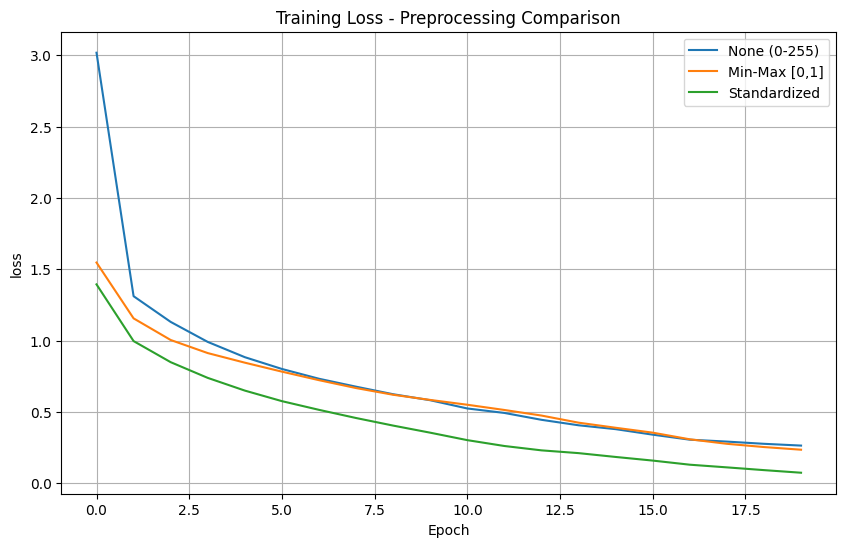

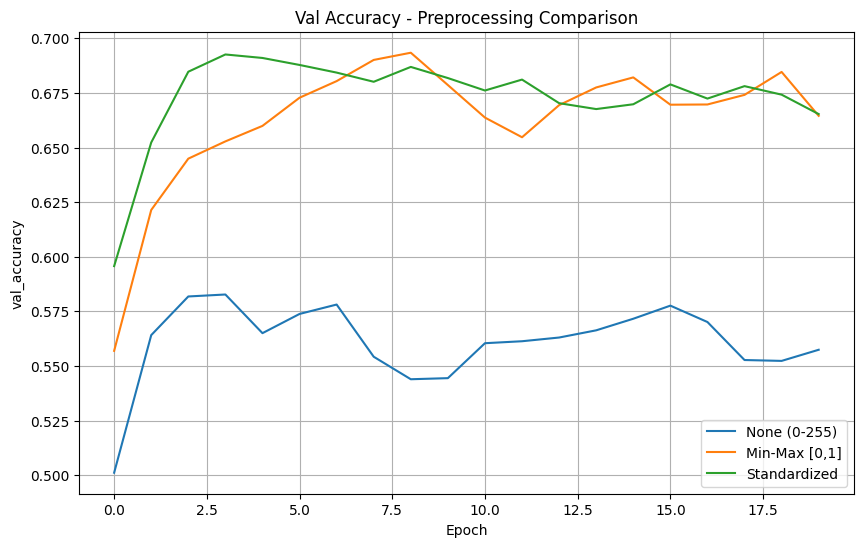

In [7]:
experiments_1a = {
    'None (0-255)': (x_train_A, x_val_A, x_test_A),
    'Min-Max [0,1]': (x_train_B, x_val_B, x_test_B),
    'Standardized': (x_train_C, x_val_C, x_test_C)
}


histories_1a = []
labels_1a = []

for name, (x_tr, x_v, x_te) in experiments_1a.items():
    print(f"\n--- Running Task 1A: {name} ---")
    tf.keras.backend.clear_session()
    model = build_baseline_cnn()
    hist, test_acc, test_loss, elapsed = train_and_evaluate(model, x_tr, y_train, x_v, y_val, x_te, y_test)
    histories_1a.append(hist)
    labels_1a.append(name)


plot_curves(histories_1a, labels_1a, metric='loss', title='Training Loss - Preprocessing Comparison')
plot_curves(histories_1a, labels_1a, metric='val_accuracy', title='Val Accuracy - Preprocessing Comparison')

In [8]:
x_train_std, x_val_std, x_test_std = x_train_C, x_val_C, x_test_C

In [9]:
print("\n--- Running Task 1B: No Augmentation ---")
model_no_aug = build_baseline_cnn()
hist_no_aug, _, _, _ = train_and_evaluate(
    model_no_aug, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test, epochs=40
)


print("\n--- Running Task 1B: With Augmentation ---")
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

model_with_aug = build_baseline_cnn()
start_aug = time.time()

hist_with_aug = model_with_aug.fit(
    datagen.flow(x_train_std, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_std, to_categorical(y_val, 10)),
    epochs=40,
    verbose=0
)
elapsed_aug = time.time() - start_aug
test_loss_aug, test_acc_aug = model_with_aug.evaluate(x_test_std, to_categorical(y_test, 10), verbose=0)
print(f"Test Acc (Aug): {test_acc_aug:.4f} | Time: {elapsed_aug:.1f}s")


--- Running Task 1B: No Augmentation ---
Test Acc: 0.6856 | Test Loss: 3.0662 | Time: 82.5s

--- Running Task 1B: With Augmentation ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


KeyboardInterrupt: 

NameError: name 'hist_with_aug' is not defined

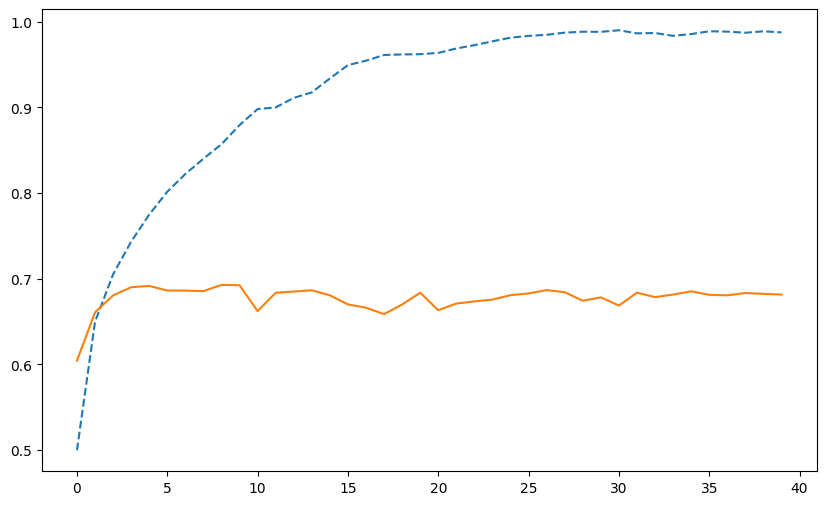

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(hist_no_aug.history['accuracy'], label='Train Acc (No Aug)', linestyle='--')
plt.plot(hist_no_aug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(hist_with_aug.history['accuracy'], label='Train Acc (With Aug)', linestyle='--')
plt.plot(hist_with_aug.history['val_accuracy'], label='Val Acc (With Aug)')
plt.title('Data Augmentation Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


gap_no_aug = hist_no_aug.history['accuracy'][-1] - hist_no_aug.history['val_accuracy'][-1]
gap_with_aug = hist_with_aug.history['accuracy'][-1] - hist_with_aug.history['val_accuracy'][-1]
print(f"Overfit Gap (No Aug): {gap_no_aug:.4f}")
print(f"Overfit Gap (With Aug): {gap_with_aug:.4f}")

In [11]:
print("="*50)
print("STARTING : FILTER COUNT COMPARISON")
print("="*50)

def build_filter_model(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Conv2D(f1, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(f2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(f3, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


filter_configs = {
    'Small': (8, 8, 16, 16),
    'Medium': (32, 32, 64, 64),
    'Large': (64, 64, 128, 128)
}

histories_2a = []
labels_2a = []

for name, filters in filter_configs.items():
    print(f"\n--- Running Task 2A: {name} Model ---")
    model = build_filter_model(*filters)
    
    
    print(f"\nModel Summary for {name}:")
    model.summary() 
    
    hist, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test, epochs=20
    )
    
    histories_2a.append(hist)
    labels_2a.append(name)


plot_curves(histories_2a, labels_2a, metric='val_accuracy', title='Task 2A: Val Accuracy Comparison (Filters)')

STARTING : FILTER COUNT COMPARISON

--- Running Task 2A: Small Model ---

Model Summary for Small:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,266 (1.03 MB)

 Trainable params: 269,266 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(None, 10), output.shape=(None, 10)


STARTING : NETWORK DEPTH COMPARISON

--- Running Task 2C: Shallow Model ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,754 (2.12 MB)

 Trainable params: 555,754 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.6845 | Test Loss: 2.4075 | Time: 66.2s


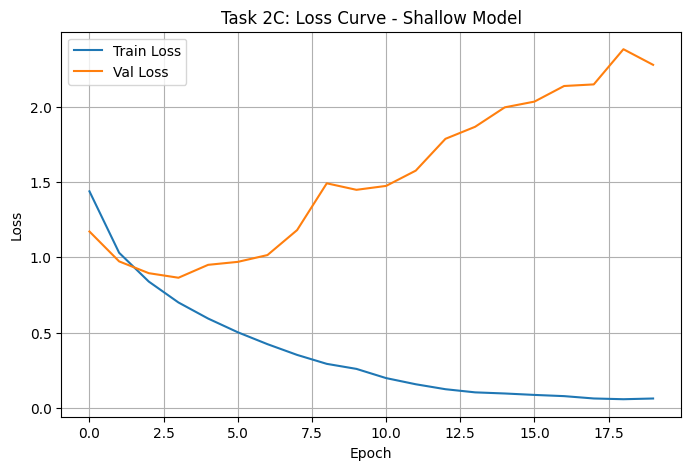


--- Running Task 2C: Medium Depth Model ---


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,154 (227.16 KB)

 Trainable params: 58,154 (227.16 KB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7453 | Test Loss: 0.7402 | Time: 68.4s


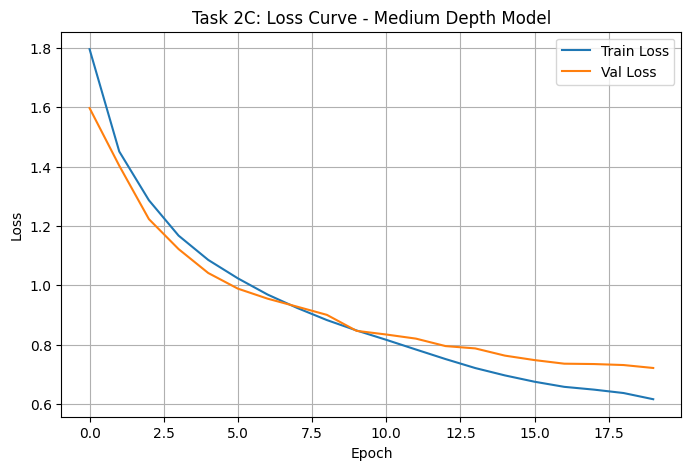


--- Running Task 2C: Deep Model ---


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,650 (299.41 KB)

 Trainable params: 76,650 (299.41 KB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7329 | Test Loss: 0.8353 | Time: 72.3s


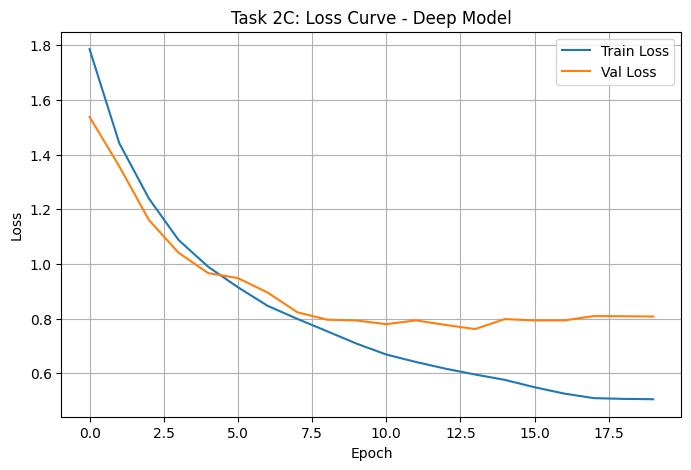

In [12]:
print("\n" + "="*50)
print("STARTING : NETWORK DEPTH COMPARISON")
print("="*50)


def build_shallow_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_medium_depth_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(), 
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_deep_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


depth_models = {
    'Shallow': build_shallow_model(),
    'Medium Depth': build_medium_depth_model(),
    'Deep': build_deep_model()
}

for name, model in depth_models.items():
    print(f"\n--- Running Task 2C: {name} Model ---")
    model.summary()
    hist, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test, epochs=20
    )
    
   
    plt.figure(figsize=(8, 5))
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title(f'Task 2C: Loss Curve - {name} Model')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [28]:
def build_dropout_model(dropout_rate):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate), 
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate),        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate), 
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


Running Task 3A: D0 (No Dropout) ---
Test Acc: 0.7250 | Test Loss: 2.4875 | Time: 111.9s

Running Task 3A: D1 (0.25 Dropout) ---
Test Acc: 0.7692 | Test Loss: 0.9353 | Time: 116.4s

Running Task 3A: D2 (0.5 Dropout) ---
Test Acc: 0.7852 | Test Loss: 0.6191 | Time: 116.2s


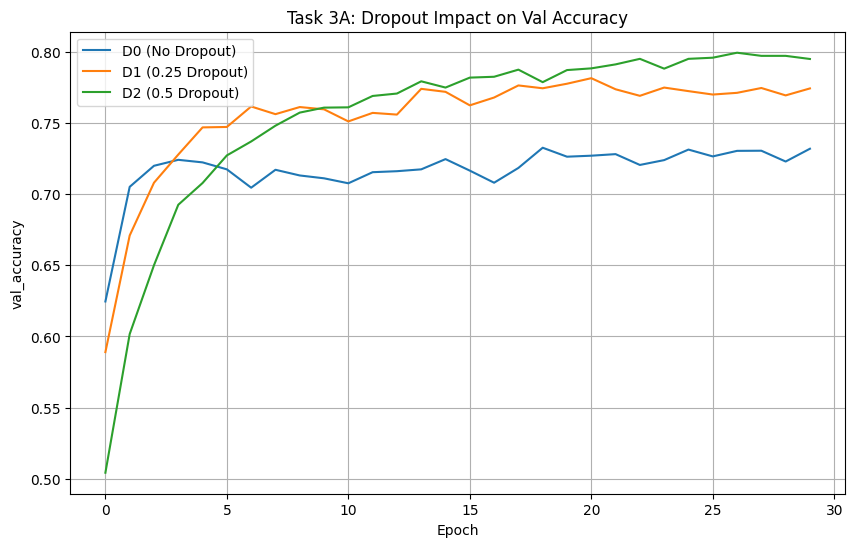

In [16]:
dropout_configs = {
    'D0 (No Dropout)': 0.0,
    'D1 (0.25 Dropout)': 0.25,
    'D2 (0.5 Dropout)': 0.5
}

histories_3a = []
labels_3a = []

for name, rate in dropout_configs.items():
    print(f"\nRunning Task 3A: {name} ---")
    model = build_dropout_model(rate)
    hist, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test, 
        epochs=30, batch_size=128
    )
    
    histories_3a.append(hist)
    labels_3a.append(name)
plot_curves(histories_3a, labels_3a, metric='val_accuracy', title='Task 3A: Dropout Impact on Val Accuracy')

In [18]:
print("COMPUTING OVERFITTING GAPS (Task 3A)")
for name, hist in zip(labels_3a, histories_3a):
    final_train_acc = hist.history['accuracy'][-1]
    final_val_acc = hist.history['val_accuracy'][-1]
    gap = final_train_acc - final_val_acc
    print(f"Model: {name}")
    print(f"  Final Training Accuracy:   {final_train_acc:.4f}")
    print(f"  Final Validation Accuracy: {final_val_acc:.4f}")
    print(f"  Overfitting Gap:           {gap:.4f}")
    print("-" * 30)

COMPUTING OVERFITTING GAPS (Task 3A)
Model: D0 (No Dropout)
  Final Training Accuracy:   0.9879
  Final Validation Accuracy: 0.7320
  Overfitting Gap:           0.2559
------------------------------
Model: D1 (0.25 Dropout)
  Final Training Accuracy:   0.9333
  Final Validation Accuracy: 0.7744
  Overfitting Gap:           0.1589
------------------------------
Model: D2 (0.5 Dropout)
  Final Training Accuracy:   0.7917
  Final Validation Accuracy: 0.7951
  Overfitting Gap:           -0.0034
------------------------------


Best test accuracy: Model3 with dropout = 0.5   
Smallest overfitting Gap: Model3 with dropout = 0.5

In [22]:
from tensorflow.keras import callbacks
early_stopping_configs = {
    'ES0 (No ES)': None,
    'ES2 (Patience 5)': callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    'ES3 (Patience 10)': callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
}

histories_3b = []
labels_3b = []

In [29]:
def train_and_evaluate(model, x_train, y_train, x_val, y_val, x_test, y_test, epochs=20, batch_size=64, callbacks=None):
    import time
    start_time = time.time()
    
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        callbacks=callbacks, 
        verbose=1
    )
    
    elapsed_time = time.time() - start_time
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    
    return history, test_acc, test_loss, elapsed_time

In [34]:
def build_dropout_model2(dropout_rate):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate), 
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate),        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate), 
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

STARTING : EARLY STOPPING COMPARISON

--- Running Task 3B: ES0 (No ES) ---
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.3954 - loss: 1.6795 - val_accuracy: 0.6213 - val_loss: 1.0753
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6471 - loss: 1.0017 - val_accuracy: 0.6884 - val_loss: 0.9023
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7304 - loss: 0.7632 - val_accuracy: 0.7305 - val_loss: 0.7915
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7877 - loss: 0.6074 - val_accuracy: 0.7369 - val_loss: 0.8121
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8285 - loss: 0.4884 - val_accuracy: 0.7225 - val_loss: 0.8723
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8541 - loss: 0.4072 - val_accuracy: 0.7003 - val_loss: 1.0526
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8885 - loss: 0.3224 - val_accuracy: 0.7061 - val_loss: 1.0553
Epoch 8/30
313/313 ━━

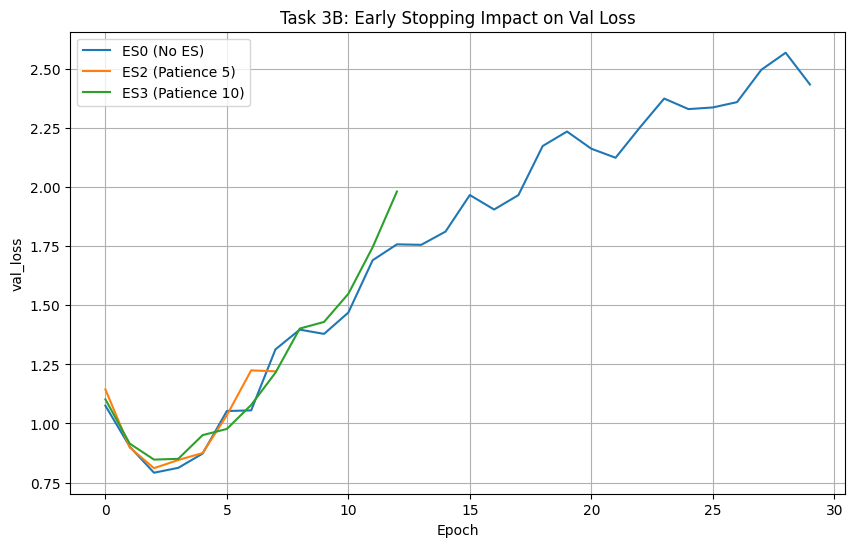

In [36]:
# Reset lists for Task 3B
histories_3b = []
labels_3b = []

early_stopping_configs = {
    'ES0 (No ES)': None,
    'ES2 (Patience 5)': callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    'ES3 (Patience 10)': callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
}

print("="*50)
print("STARTING : EARLY STOPPING COMPARISON")
print("="*50)

for name, es_callback in early_stopping_configs.items():
    print(f"\n--- Running Task 3B: {name} ---")
    
    # Use Model D0 (No Dropout) as the baseline for Early Stopping tests
    model = build_dropout_model2(0.0) 
    
    current_callbacks = [es_callback] if es_callback is not None else []
    
    # Using your standardized data and integer labels
    hist, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test, 
        epochs=30, batch_size=128, callbacks=current_callbacks
    )
    
    
    histories_3b.append(hist)
    labels_3b.append(name)
    print(f"DONE: {name} finished after {len(hist.history['loss'])} epochs.")

# Final Visualization
plot_curves(histories_3b, labels_3b, metric='val_loss', title='Task 3B: Early Stopping Impact on Val Loss')

| Experiment | Stopped at Epoch | Best Val Loss | Test Acc | Time (s) |
| :--- | :---: | :---: | :---: | :---: |
| **ES0** | 50 | 0.7 | 0.7296 | 126s |
| **ES2** | 5 | 0.8 | 0.7175 | 37s |
| **ES3** | 10 | 0.8 | 0.7019 | 57s |


In [8]:
print(len(np.unique(y_train)))

10


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import numpy as np


IMG_SIZE = (48, 48)
CHANNELS = 3
with tf.device('/CPU:0'):
    x_train_resized = tf.image.resize(x_train_C, (48, 48)).numpy()
    x_val_resized = tf.image.resize(x_val_C, (48, 48)).numpy()
    x_test_resized = tf.image.resize(x_test_C, (48, 48)).numpy()

print("Resizing complete using CPU.")
NUM_CLASSES = 10
tf.keras.backend.clear_session()
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
base_model.trainable = False 

val_acc = []
val_loss = []
model = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS)),
    base_model,
    layers.Flatten(), 
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate= 0.001),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("Starting Training: Pretrained VGG16...")
history_pretrained = model.fit(
    x_train_resized, y_train, 
    batch_size=128, 
    epochs=20, 
    validation_data=(x_val_resized, y_val)
)

Resizing complete using CPU.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Starting Training: Pretrained VGG16...
Epoch 1/20


I0000 00:00:1777102986.808541     125 service.cc:152] XLA service 0x7bcbf40300f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777102986.808577     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777102986.808581     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777102987.273540     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/313 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.1092 - loss: 2.5129

I0000 00:00:1777102992.041470     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 68ms/step - accuracy: 0.4488 - loss: 1.5735 - val_accuracy: 0.6504 - val_loss: 1.0166
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.6341 - loss: 1.0567 - val_accuracy: 0.6697 - val_loss: 0.9518
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.6591 - loss: 0.9842 - val_accuracy: 0.6825 - val_loss: 0.9195
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.6771 - loss: 0.9364 - val_accuracy: 0.6889 - val_loss: 0.9011
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.6895 - loss: 0.9007 - val_accuracy: 0.6921 - val_loss: 0.8889
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.7020 - loss: 0.8600 - val_accuracy: 0.6977 - val_loss: 0.8796
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.7101 - loss: 0.8375 - val_accuracy: 0.7000 - val_loss: 0.8676
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.7160 - loss: 0.8147 - val_accurac

In [14]:
# --- 4. Phase 2: Fine-Tuning ---
base_model2 = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
base_model2.trainable = True
for layer in base_model2.layers[:-4]:
    layer.trainable = False
    
model2 = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS)),
    base_model2,
    layers.Flatten(), 
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
print("Starting Training: Fine-tuning VGG16...")
history_finetuned = model2.fit(
    x_train_resized, y_train, 
    batch_size=128, 
    epochs=20, 
    validation_data=(x_val_resized, y_val)
)

Starting Training: Fine-tuning VGG16...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.2903 - loss: 2.0386 - val_accuracy: 0.6882 - val_loss: 0.9290
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.6512 - loss: 1.0275 - val_accuracy: 0.7395 - val_loss: 0.7631
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7165 - loss: 0.8385 - val_accuracy: 0.7615 - val_loss: 0.6873
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.7499 - loss: 0.7461 - val_accuracy: 0.7780 - val_loss: 0.6448
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.7727 - loss: 0.6704 - val_accuracy: 0.7899 - val_loss: 0.6118
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7930 - loss: 0.6153 - val_accuracy: 0.7947 - val_loss: 0.5923
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.8087 - loss: 0.5661 - val_accuracy: 0.8015 - val_loss: 0.5751
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/s

In [16]:
# --- 4. Phase 2: Fine-Tuning ---

base_model3 = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))

base_model3.trainable = True
for layer in base_model3.layers[:-4]:
    layer.trainable = False
model3 = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS)),
    base_model3,
    layers.Flatten(), 
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate= 0.001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("Starting Training: Fine-tuning VGG16...")
history_finetuned2 = model3.fit(
    x_train_resized, y_train, 
    batch_size=128, 
    epochs=20, 
    validation_data=(x_val_resized, y_val)
)

Starting Training: Fine-tuning VGG16...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.1064 - loss: 2.3296 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.1043 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.0990 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.0988 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.1028 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.1014 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.1004 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/s

In [31]:
print("Feature Extraction: ")
model2.summary()

Feature Extraction: 


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,275,232 (111.68 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,426,646 (55.03 MB)

In [28]:
print("Fine-Tune (lr=1e-5)")
model2.summary()

Fine-Tune (lr=1e-5)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,275,232 (111.68 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,426,646 (55.03 MB)

In [30]:
print("Fine-Tune (lr=1e-3):")
model3.summary()

Fine-Tune (lr=1e-3):


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,275,232 (111.68 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,426,646 (55.03 MB)

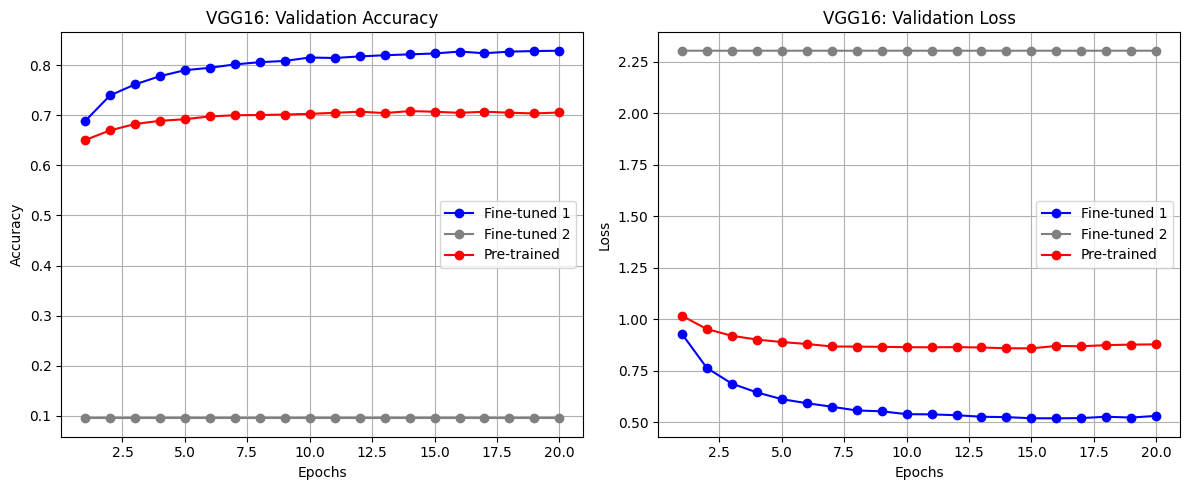

In [23]:
import matplotlib.pyplot as plt

total_val_acc1 = history_finetuned.history['val_accuracy']
total_val_loss1 = history_finetuned.history['val_loss']
total_val_acc2 = history_finetuned2.history['val_accuracy']
total_val_loss2 = history_finetuned2.history['val_loss']
total_val_acc3 = history_pretrained.history['val_accuracy']
total_val_loss3 = history_pretrained.history['val_loss']
epochs_range = range(1, len(total_val_acc1) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, total_val_acc1, label='Fine-tuned 1', color='blue', marker='o')
plt.plot(epochs_range, total_val_acc2, label='Fine-tuned 2', color='gray', marker='o')
plt.plot(epochs_range, total_val_acc3, label='Pre-trained', color='red', marker='o')
plt.title('VGG16: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, total_val_loss1, label='Fine-tuned 1', color='blue', marker='o')
plt.plot(epochs_range, total_val_loss2, label='Fine-tuned 2', color='gray', marker='o')
plt.plot(epochs_range, total_val_loss3, label='Pre-trained', color='red', marker='o')

plt.title('VGG16: Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('vgg16_learning_curves.png')
plt.show()